In [1]:
#libraries
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler,Subset
from sklearn.metrics import classification_report
from avex import load_model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, 
    roc_curve, multilabel_confusion_matrix
)
from tqdm import tqdm

import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import random
import math

import soundfile as sf

c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-p

In [3]:
# 1. Dimensionality reduction and clustering metrics
# Plotting helpers
def create_composition_labels(y_matrix, label_names):
    comp_labels = []
    for row in y_matrix:
        active = [label_names[i] for i, val in enumerate(row) if val == 1]
        if not active:
            comp_labels.append("Silence/Other")
        else:
            comp_labels.append(" + ".join(active))
    return comp_labels

import matplotlib.colors as mcolors

# 1. Define distinct base colors for your 5 categories
base_colors = {
    'Type A': '#1f77b4', # Blue
    'Type B': '#ff7f0e', # Orange
    'Type C': '#2ca02c', # Green
    'Type D': '#d62728', # Red
    'Echo':   '#9467bd'  # Purple
}

def mix_multi_labels(row, label_names, base_colors):
    """
    Finds all active labels in a row and averages their RGB colors.
    """
    active_indices = [i for i, val in enumerate(row) if val == 1]
    
    if not active_indices:
        return mcolors.to_rgb('#e0e0e0') # Light grey for unlabeled/silence
    
    # Get RGB tuples for all active labels
    rgbs = [mcolors.to_rgb(base_colors[label_names[i]]) for i in active_indices]
    
    # Average the RGB values
    mixed_rgb = np.mean(rgbs, axis=0)
    return mixed_rgb

Running PCA...
Running UMAP...
Running t-SNE...


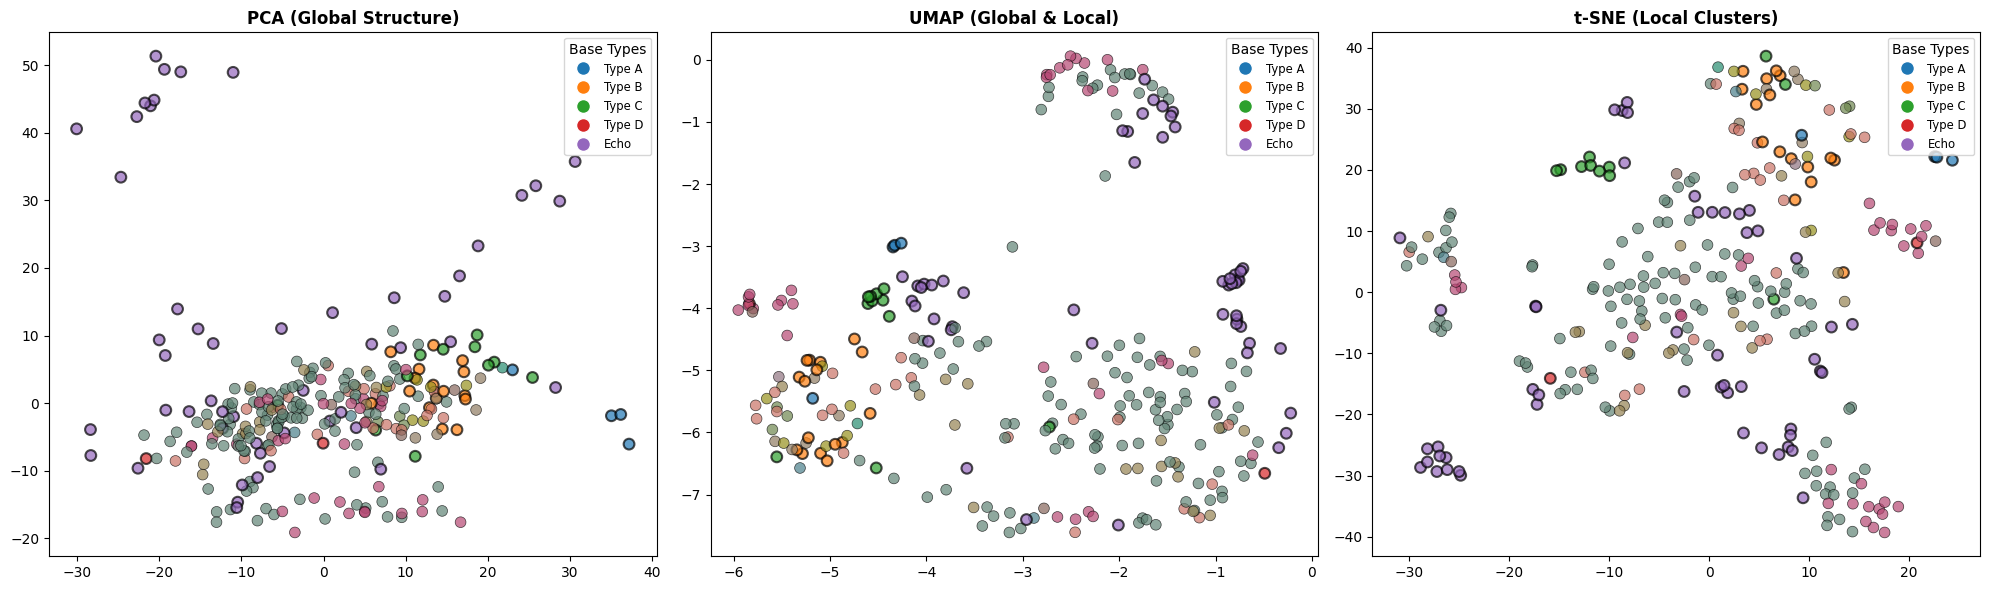

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
import umap

# 1. Load Data
X = np.load("X_features2_not_normalized.npy")
y = np.load("Y_labels2_not_normalized.npy")


# Usage
label_names = ['A', 'B', 'C', 'D', 'Echo']
color_labels = create_composition_labels(y, label_names)
# Generate the color array for your data
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
point_colors = [mix_multi_labels(row, label_names, base_colors) for row in y]


# 2. Preprocessing (Standard Scaling is CRITICAL)
#  Average the windows and Scale the data
#X_2d_max = np.max(X, axis=(3,2)) if X.ndim == 4 else X
#X_scaled_max = StandardScaler().fit_transform(X_2d_max )

X_2d_mean = np.mean(X, axis=(3,2)) if X.ndim == 4 else X
X_scaled = StandardScaler().fit_transform(X_2d_mean)


# 3. Apply Dimensionality Reduction
print("Running PCA...")
pca_res = PCA(n_components=2).fit_transform(X_scaled)

print("Running UMAP...")
umap_res = umap.UMAP(n_neighbors=50, min_dist=0.1, metric='cosine').fit_transform(X_scaled)

print("Running t-SNE...")
tsne_res = TSNE(n_components=2, perplexity=15, init='pca', learning_rate='auto').fit_transform(X_scaled)

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['PCA (Global Structure)', 'UMAP (Global & Local)', 't-SNE (Local Clusters)']
results = [pca_res, umap_res, tsne_res]

for i, res in enumerate(results):
    ax = axes[i]
    
    
    edge_widths = [1.5 if row.sum() == 1 else 0.5 for row in y]
    
    # Use ax.scatter instead of sns.scatterplot
    # This allows us to pass our mixed 'point_colors' directly to 'c'
    ax.scatter(
        res[:, 0], res[:, 1], 
        c=point_colors, 
        s=60, alpha=0.7, 
        edgecolor='black', 
        linewidth=edge_widths
    )
    
    ax.set_title(titles[i], fontweight='bold')
    
    # Since we aren't using Seaborn's auto-legend, we add a manual one
    # using the base_colors dictionary we defined earlier
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=k,
               markerfacecolor=v, markersize=10) 
        for k, v in base_colors.items()
    ]
    ax.legend(handles=legend_elements, title="Base Types", loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()


UNIQUE LABEL COMBINATION CLUSTERING METRICS
                   silhouette  davies_bouldin  calinski_harabasz  purity
encoder                                                                 
effnetb0-all mean     -0.1062          3.2751             4.3238  0.5532

ONE-vs-REST CLUSTERING METRICS  (per call type)

  Encoder: effnetb0-all mean
        silhouette  davies_bouldin  calinski_harabasz
label                                                
Type A      0.0804          2.9154             5.9335
Type B     -0.0255          4.2223             8.4237
Type C      0.0476          5.8419             7.2125
Type D     -0.0016          4.2512             5.5626
Echo        0.0578          3.1197            13.0054


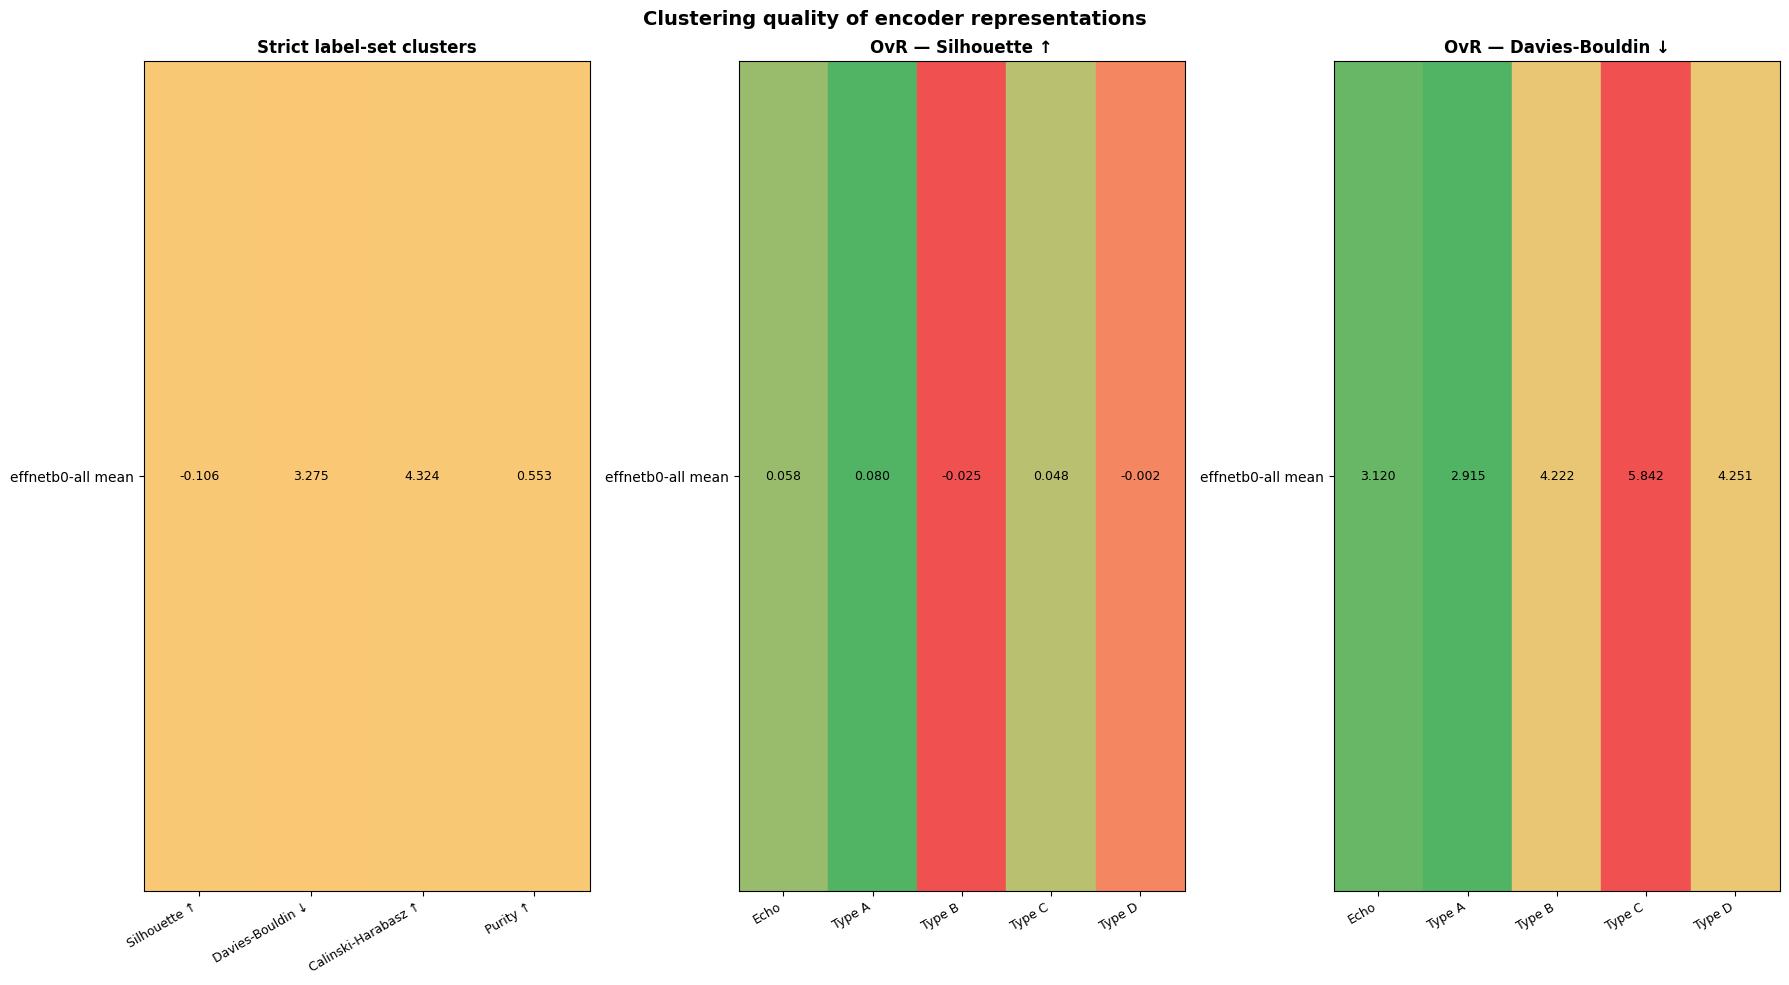

In [11]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
from itertools import combinations

# ── helpers ──────────────────────────────────────────────────────────────────

def cluster_purity(embeddings_2d, string_labels):
    """
    Purity: for each unique label-set cluster, what fraction of its
    nearest-cluster members share the majority label?
    Here we use the label assignments themselves as 'clusters'.
    """
    le = LabelEncoder()
    int_labels = le.fit_transform(string_labels)
    unique = np.unique(int_labels)
    total = 0
    for cl in unique:
        mask = int_labels == cl
        # majority label within this cluster is itself (pure by definition
        # for composition labels), so purity = fraction of dataset in
        # pure clusters — useful when compared across encoders.
        total += mask.sum()
    # True inter-cluster purity requires a predicted clustering;
    # here we expose per-label cohesion via silhouette instead.
    # This function computes *overall purity* of a k-means fit for comparison.
    from sklearn.cluster import KMeans
    k = len(unique)
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(embeddings_2d)
    pred = km.labels_
    purity = 0.0
    for cl in np.unique(pred):
        mask = pred == cl
        true_in_cluster = int_labels[mask]
        counts = np.bincount(true_in_cluster, minlength=len(unique))
        purity += counts.max()
    return purity / len(int_labels)


def compute_strict_metrics(embedding, comp_labels):
    """
    Treat every unique label-combination as its own cluster.
    Requires at least 2 distinct labels and >=2 samples per label.
    """
    le = LabelEncoder()
    int_labels = le.fit_transform(comp_labels)

    # Drop clusters with only 1 sample (metrics undefined for singletons)
    counts = np.bincount(int_labels)
    valid_mask = np.isin(int_labels, np.where(counts >= 2)[0])
    emb_v = embedding[valid_mask]
    lbl_v = int_labels[valid_mask]

    n_clusters = len(np.unique(lbl_v))
    if n_clusters < 2:
        return {k: np.nan for k in
                ["silhouette", "davies_bouldin", "calinski_harabasz", "purity"]}

    return {
        "silhouette":          silhouette_score(emb_v, lbl_v, metric="euclidean"),
        "davies_bouldin":      davies_bouldin_score(emb_v, lbl_v),
        "calinski_harabasz":   calinski_harabasz_score(emb_v, lbl_v),
        "purity":              cluster_purity(emb_v,
                                   np.array(comp_labels)[valid_mask]),
    }


def compute_ovr_metrics(embedding, y_matrix, label_names):
    """
    One-vs-Rest: for each call type, treat positive samples as cluster 1
    and negatives as cluster 0.  Returns a dict-of-dicts keyed by label name.
    """
    results = {}
    for i, name in enumerate(label_names):
        binary = y_matrix[:, i].astype(int)
        n_pos = binary.sum()
        n_neg = (binary == 0).sum()

        if n_pos < 2 or n_neg < 2:          # not enough samples
            results[name] = {k: np.nan for k in
                             ["silhouette", "davies_bouldin",
                              "calinski_harabasz"]}
            continue

        results[name] = {
            "silhouette":        silhouette_score(embedding, binary,
                                                  metric="euclidean"),
            "davies_bouldin":    davies_bouldin_score(embedding, binary),
            "calinski_harabasz": calinski_harabasz_score(embedding, binary),
        }
    return results


def compute_all_metrics(embedding_dict, y_matrix, label_names):
    """
    Run both metric sets for every named embedding.

    Parameters
    ----------
    embedding_dict : dict  e.g. {"PCA": pca_res, "UMAP": umap_res, ...}
    y_matrix       : (N, C) binary numpy array
    label_names    : list of C strings

    Returns
    -------
    strict_df : pd.DataFrame  — one row per encoder
    ovr_df    : pd.DataFrame  — one row per (encoder × label)
    """
    import pandas as pd

    comp_labels = create_composition_labels(y_matrix, label_names)

    strict_rows, ovr_rows = [], []

    for enc_name, emb in embedding_dict.items():
        # ── strict ──
        s = compute_strict_metrics(emb, comp_labels)
        strict_rows.append({"encoder": enc_name, **s})

        # ── one-vs-rest ──
        ovr = compute_ovr_metrics(emb, y_matrix, label_names)
        for lbl, metrics in ovr.items():
            ovr_rows.append({"encoder": enc_name, "label": lbl, **metrics})

    strict_df = pd.DataFrame(strict_rows).set_index("encoder")
    ovr_df    = pd.DataFrame(ovr_rows)

    return strict_df, ovr_df


# ── pretty-print / plot helper ────────────────────────────────────────────────

def print_metric_tables(strict_df, ovr_df):
    import pandas as pd
    pd.set_option("display.float_format", "{:.4f}".format)

    print("\n" + "="*60)
    print("UNIQUE LABEL COMBINATION CLUSTERING METRICS")
    print("="*60)
    print(strict_df.to_string())

    print("\n" + "="*60)
    print("ONE-vs-REST CLUSTERING METRICS  (per call type)")
    print("="*60)
    for enc in ovr_df["encoder"].unique():
        sub = ovr_df[ovr_df["encoder"] == enc].set_index("label")
        print(f"\n  Encoder: {enc}")
        print(sub[["silhouette", "davies_bouldin",
                   "calinski_harabasz"]].to_string())

def make_cmap(higher_is_better):
    colors = ["#f05050", "#fac875", "#50b464"]
    if not higher_is_better:
        colors = colors[::-1]
    return mcolors.LinearSegmentedColormap.from_list("metric", colors)

def plot_metric_heatmaps(strict_df, ovr_df, figsize=(18, 10)):
    import pandas as pd
    import matplotlib.colors as mcolors

    metric_config = {
        "silhouette":        {"higher": True,  "label": "Silhouette ↑"},
        "davies_bouldin":    {"higher": False, "label": "Davies-Bouldin ↓"},
        "calinski_harabasz": {"higher": True,  "label": "Calinski-Harabasz ↑"},
        "purity":            {"higher": True,  "label": "Purity ↑"},
    }

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle("Clustering quality of encoder representations",
                 fontsize=14, fontweight="bold")

    # ── left: strict metrics ──
    ax = axes[0]
    metrics_strict = [m for m in metric_config if m in strict_df.columns]
    data = strict_df[metrics_strict].astype(float)

    for c_idx, metric in enumerate(metrics_strict):
        cfg = metric_config[metric]
        col_vals = data.iloc[:, c_idx].values
        vmin, vmax = col_vals.min(), col_vals.max()
        cmap = make_cmap(cfg["higher"])
        for r_idx, val in enumerate(col_vals):
            norm_val = (val - vmin) / (vmax - vmin) if vmax != vmin else 0.5
            color = cmap(norm_val)
            ax.add_patch(plt.Rectangle((c_idx - 0.5, r_idx - 0.5), 1, 1,
                                       color=color, zorder=0))
            ax.text(c_idx, r_idx, f"{val:.3f}",
                    ha="center", va="center", fontsize=9, zorder=1)

    ax.set_xlim(-0.5, len(metrics_strict) - 0.5)
    ax.set_ylim(-0.5, len(data) - 0.5)
    ax.set_xticks(range(len(metrics_strict)))
    ax.set_xticklabels([metric_config[m]["label"] for m in metrics_strict],
                       rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.set_title("Strict label-set clusters", fontweight="bold")
    ax.invert_yaxis()

    # ── centre & right: OvR silhouette and DB per encoder ──
    for ax_idx, metric in enumerate(["silhouette", "davies_bouldin"], start=1):
        ax = axes[ax_idx]
        cfg = metric_config[metric]
        pivot = ovr_df.pivot(index="encoder", columns="label",
                             values=metric).astype(float)
        cmap = make_cmap(cfg["higher"])
        vmin, vmax = pivot.values.min(), pivot.values.max()

        for r_idx in range(pivot.shape[0]):
            for c_idx in range(pivot.shape[1]):
                val = pivot.values[r_idx, c_idx]
                norm_val = (val - vmin) / (vmax - vmin) if vmax != vmin else 0.5
                color = cmap(norm_val)
                ax.add_patch(plt.Rectangle((c_idx - 0.5, r_idx - 0.5), 1, 1,
                                           color=color, zorder=0))
                ax.text(c_idx, r_idx, f"{val:.3f}",
                        ha="center", va="center", fontsize=9, zorder=1)

        ax.set_xlim(-0.5, pivot.shape[1] - 0.5)
        ax.set_ylim(-0.5, pivot.shape[0] - 0.5)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)
        ax.set_title(f"OvR — {cfg['label']}", fontweight="bold")
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

# ── usage ─────────────────────────────────────────────────────────────────────

label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

# Use the full-dimensional scaled embedding, NOT the 2D projections
#embedding_dict = {
#    "effnetb0-all": X_scaled,   # add other encoders here when comparing
#}

embedding_dict = {
    #"PCA":   pca_res,
    #"UMAP":  umap_res,
    #"t-SNE": tsne_res,
     "effnetb0-all mean": X_scaled,
}

strict_df, ovr_df = compute_all_metrics(embedding_dict, y, label_names)
print_metric_tables(strict_df, ovr_df)
plot_metric_heatmaps(strict_df, ovr_df)

In [ ]:
#Unsupervised metrics
